In [1]:
print("Hello")

Hello


In [5]:
# Core utilities
import os
import sys
import time
import datetime
import warnings
warnings.filterwarnings("ignore")
# Data handling
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
# Deep Learning (CNN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Image processing
import cv2
from PIL import Image
import streamlit as st
import joblib


In [3]:
data = pd.read_csv("crop_recommendation\Crop_recommendation.csv")
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
data.size

17600

In [7]:
data.shape


(2200, 8)

In [8]:
data.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [9]:
data.duplicated().sum()


np.int64(0)

In [10]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])


In [11]:
Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1


In [12]:
data = data[~((numeric_data < (Q1 - 1.5 * IQR)) | 
              (numeric_data > (Q3 + 1.5 * IQR))).any(axis=1)]


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import joblib
# Features (7)
X = data[['N','P','K','temperature','humidity','ph','rainfall']]
y = data['label']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Model
model = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained successfully")
# Save model
joblib.dump(model,"models/crop_model_7.pkl")
joblib.dump(scaler,"models/crop_scaler_7.pkl")
print("Model saved")

Model trained successfully
Model saved


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y) # use le


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

# Train
crop_model = RandomForestClassifier(n_estimators=200, random_state=42)
crop_model.fit(X_train, y_train)

print("Model expects features:", crop_model.n_features_in_)  # MUST PRINT 7

# Save
os.makedirs("models", exist_ok=True)

joblib.dump(crop_model, "models/crop_model.pkl")
joblib.dump(scaler, "models/crop_scaler.pkl")
joblib.dump(le, "models/crop_label.pkl")

print("✅ Fresh 7-feature model saved")


Model expects features: 7
✅ Fresh 7-feature model saved


In [16]:
X = data.drop('label', axis=1)
y = data['label'] 

In [17]:
crop_model = joblib.load("models/crop_model.pkl")
scaler = joblib.load("models/crop_scaler.pkl")
label_encoder = joblib.load("models/crop_label.pkl")

In [18]:
def recommend_crop(N, P, K, temp, humidity, ph, rainfall):

    data = np.array([[N, P, K, temp, humidity, ph, rainfall]])

    data_scaled = scaler.transform(data)

    prediction = crop_model.predict(data_scaled)

    crop = label_encoder.inverse_transform(prediction)[0]

    return crop

In [19]:
loaded_model = joblib.load("models/crop_model.pkl")
print("Loaded model features:", loaded_model.n_features_in_)

Loaded model features: 7


In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy * 100, "%")


Model Accuracy: 98.87005649717514 %


In [29]:
print(data['label'].value_counts())

label
maize          100
kidneybeans    100
mungbean       100
pigeonpeas     100
coffee         100
cotton         100
blackgram      100
lentil         100
banana         100
pomegranate    100
muskmelon      100
watermelon     100
jute           100
mango           98
coconut         85
orange          83
mothbeans       58
chickpea        58
papaya          54
rice            32
Name: count, dtype: int64


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        23
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        18
           5       0.95      1.00      0.97        18
           6       0.84      1.00      0.91        16
           7       1.00      1.00      1.00        22
           8       1.00      1.00      1.00        18
           9       1.00      0.95      0.97        19
          10       1.00      1.00      1.00        18
          11       1.00      1.00      1.00        14
          12       1.00      1.00      1.00        18
          13       1.00      1.00      1.00        18
          14       1.00      1.00      1.00        14
          15       1.00      1.00      1.00        13
          16       1.00      1.00      1.00        23
          17       1.00    

In [23]:
DATASET_PATH ="plantvillage"


In [24]:
data.size

14144

In [25]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator



In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [29]:
train_dir = r"C:\Users\SBhar\OneDrive\Desktop\smartcropproject\plantvillage"
val_dir = r"C:\Users\SBhar\OneDrive\Desktop\smartcropproject\plantvillage"

In [30]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 8345 images belonging to 7 classes.


In [31]:
val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

Found 8345 images belonging to 7 classes.


In [32]:

img_size = 128
batch_size = 16

dataset_path = r"C:\Users\SBhar\OneDrive\Desktop\smartcropproject\plantvillage"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

print(train_data.class_indices)

Found 6678 images belonging to 7 classes.
Found 1667 images belonging to 7 classes.
{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_healthy': 6}


In [33]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
weights='imagenet',
include_top=False,
input_shape=(128,128,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)

predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 64, 64, 32)        │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 64, 64, 32)        │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 64, 64, 32)        │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 64, 64, 32)        │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 64, 64, 32)        │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 64, 64, 32)        │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 64, 64, 16)        │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 64, 64, 16)        │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 64, 64, 96)        │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 64, 64, 96)        │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 64, 64, 96)        │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 65, 65, 96)        │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 32, 32, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
418/418 ━━━━━━━━━━━━━━━━━━━━ 1210s 3s/step - accuracy: 0.9376 - loss: 0.1853 - val_accuracy: 0.9772 - val_loss: 0.0749
Epoch 2/5
418/418 ━━━━━━━━━━━━━━━━━━━━ 99s 237ms/step - accuracy: 0.9801 - loss: 0.0551 - val_accuracy: 0.9826 - val_loss: 0.0630
Epoch 3/5
418/418 ━━━━━━━━━━━━━━━━━━━━ 143s 240ms/step - accuracy: 0.9910 - loss: 0.0278 - val_accuracy: 0.9760 - val_loss: 0.0786
Epoch 4/5
418/418 ━━━━━━━━━━━━━━━━━━━━ 144s 243ms/step - accuracy: 0.9972 - loss: 0.0121 - val_accuracy: 0.9874 - val_loss: 0.0529
Epoch 5/5
418/418 ━━━━━━━━━━━━━━━━━━━━ 140s 237ms/step - accuracy: 0.9964 - loss: 0.0115 - val_accuracy: 0.9820 - val_loss: 0.0559


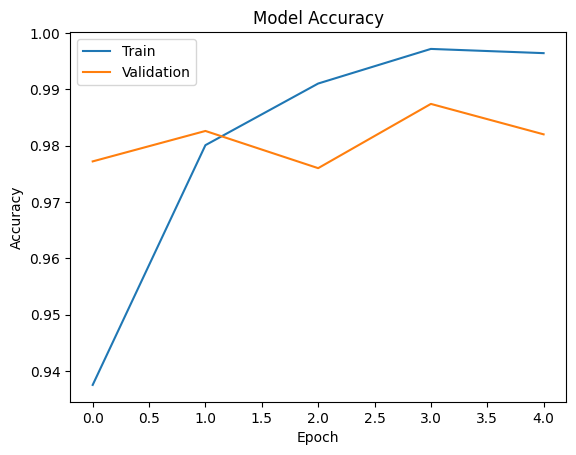

In [35]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()    

In [36]:
model.save("plant_disease_model.h5")

In [37]:
model = tf.keras.models.load_model("plant_disease_model.h5")

In [38]:
import cv2
import numpy as np

class_names = list(train_data.class_indices.keys())

def predict_image(img_path):

    img = cv2.imread(img_path)

    if img is None:
        print("Image not found")
        return

    img = cv2.resize(img,(128,128))
    img = img/255.0
    img = np.reshape(img,[1,128,128,3])

    prediction = model.predict(img)

    class_index = np.argmax(prediction)

    print("Predicted Disease:",class_names[class_index])

In [40]:
predict_image("peb.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Disease: Pepper__bell___Bacterial_spot


In [42]:
def crop_leaf(image_path):

    img = cv2.imread(image_path)

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray,(5,5),0)

    _,thresh = cv2.threshold(blur,120,255,cv2.THRESH_BINARY_INV)

    contours,_ = cv2.findContours(thresh,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    c = max(contours,key=cv2.contourArea)

    x,y,w,h = cv2.boundingRect(c)

    leaf = img[y:y+h,x:x+w]

    cv2.imwrite("cropped_leaf.jpg",leaf)

    return "cropped_leaf.jpg"

In [11]:
fertilizer_data = pd.read_csv("fertilizer_recommendation/Fertilizer Prediction.csv")
fertilizer_data.head()

,Temparature,humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


In [12]:
fertilizer_data.columns = fertilizer_data.columns.str.strip().str.lower()

In [44]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Load dataset
data = pd.read_excel("soil_based_crop_season_dataset.xlsx")

print(data.columns)

# Encoders
le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_season = LabelEncoder()

data["soil_type"] = le_soil.fit_transform(data["soil_type"])
data["crop"] = le_crop.fit_transform(data["crop"])
data["season"] = le_season.fit_transform(data["season"])


# Features
X = data[[
    "soil_type",
    "temperature_C",
    "humidity_percent",
    "rainfall_mm",
    "season"
]]

# Target (Crop recommendation)
y = data["crop"]


# Train Model
model = RandomForestClassifier(n_estimators=150)

model.fit(X,y)


# Save Models
joblib.dump(model,"models/crop_model.pkl")
joblib.dump(le_soil,"models/soil_encoder.pkl")
joblib.dump(le_crop,"models/crop_encoder.pkl")
joblib.dump(le_season,"models/season_encoder.pkl")

print("✅ Crop model saved")

Index(['soil_type', 'temperature_C', 'humidity_percent', 'rainfall_mm',
       'season', 'crop'],
      dtype='object')
✅ Crop model saved


In [45]:
fertilizer_recommendation = {

"Pepper_bell__Bacterial_spot":
"Apply copper-based bactericide. Use balanced NPK fertilizer.",

"Pepper_bell__healthy":
"Plant is healthy. Apply organic compost to maintain growth.",

"Potato__Early_blight":
"Use fungicide like Mancozeb. Apply potassium rich fertilizer.",

"Potato__healthy":
"Plant is healthy. Maintain soil nutrients with NPK fertilizer.",

"Potato__Late_blight":
"Use fungicide like Metalaxyl. Avoid overwatering.",

"Tomato_Bacterial_spot":
"Apply copper fungicide. Use calcium nitrate fertilizer.",

"Tomato_healthy":
"Plant is healthy. Apply organic manure for better yield."
}

In [46]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model("plant_disease_model.h5")

class_names = [
"Pepper_bell__Bacterial_spot",
"Pepper_bell__healthy",
"Potato__Early_blight",
"Potato__healthy",
"Potato__Late_blight",
"Tomato_Bacterial_spot",
"Tomato_healthy"
]

def predict_disease(img):

    img = cv2.resize(img,(128,128))
    img = img/255.0
    img = np.reshape(img,[1,128,128,3])

    prediction = model.predict(img)

    class_index = np.argmax(prediction)

    disease = class_names[class_index]

    fertilizer = fertilizer_recommendation[disease]

    return disease,fertilizer

In [47]:
import requests
import numpy as np
import joblib

# ==============================
# LOAD MODELS
# ==============================

crop_model = joblib.load("crop_model.pkl")
scaler = joblib.load("models/crop_scaler.pkl")
label_encoder = joblib.load("models/crop_label.pkl")

# ==============================
# WEATHER FUNCTION
# ==============================

API_KEY = "YOUR_OPENWEATHER_API_KEY"

def get_weather_data(lat, lon):
    url = f"http://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
    
    response = requests.get(url)
    data = response.json()

    if response.status_code == 200:
        temperature = data["main"]["temp"]
        humidity = data["main"]["humidity"]
        rainfall = data.get("rain", {}).get("1h", 0)

        return temperature, humidity, rainfall
    else:
        return None

# ==============================
# CROP RECOMMENDATION
# ==============================

def recommend_crop(N, P, K, temp, humidity, ph, rainfall):
    dummy_label = 0  # only if model expects 8 features
    data = np.array([[N, P, K, temp, humidity, ph, rainfall, dummy_label]])
    data = scaler.transform(data)
    pred = crop_model.predict(data)
    return label_encoder.inverse_transform(pred)[0]


In [48]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
img_size = 224
batch_size = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "Soil-Dataset",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
     "Soil-Dataset",
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

print(train_data.class_indices)

Found 127 images belonging to 5 classes.
Found 31 images belonging to 5 classes.
{'Black Soil': 0, 'Laterite Soil': 1, 'clay Soil': 2, 'red Soil': 3, 'sandy Soil': 4}


In [49]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [50]:
soil_classes = ['Black Soil','Clay Soil','Laterite Soil','Red Soil','Sandy Soil']

In [51]:
import os
os.listdir("models")

['.ipynb_checkpoints',
 'crop_encoder.pkl',
 'crop_label.pkl',
 'crop_label_new.pkl',
 'crop_model.pkl',
 'crop_model_7.pkl',
 'crop_model_new.pkl',
 'crop_scaler.pkl',
 'crop_scaler_7.pkl',
 'disease_classes.pkl',
 'disease_model.h5',
 'disease_model.keras',
 'fertilizer_encoder.pkl',
 'fertilizer_model.pkl',
 'season_encoder.pkl',
 'soil_encoder.pkl',
 'soil_model.h5']

In [52]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [53]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128,activation='relu')(x)

predictions = Dense(train_data.num_classes,activation='softmax')(x)

model = Model(inputs=base_model.input,outputs=predictions)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [94]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.4016 - loss: 1.4576 - val_accuracy: 0.6452 - val_loss: 0.9873
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.8031 - loss: 0.6268 - val_accuracy: 0.7742 - val_loss: 0.8208
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8898 - loss: 0.3791 - val_accuracy: 0.7742 - val_loss: 0.7023
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 946ms/step - accuracy: 0.9449 - loss: 0.2288 - val_accuracy: 0.8065 - val_loss: 0.6689
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 873ms/step - accuracy: 0.9685 - loss: 0.1480 - val_accuracy: 0.8387 - val_loss: 0.6666
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 923ms/step - accuracy: 0.9921 - loss: 0.0923 - val_accuracy: 0.7742 - val_loss: 0.6751
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 1.0000 - loss: 0.0673 - val_accuracy: 0.8065 - val_loss: 0.6791
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 938ms/step - accuracy: 1.0000 - loss: 0.0514 - val_accuracy: 0.8065 - val_loss: 0.6709


In [95]:
model.save("soil_model.h5")

In [96]:
from tensorflow.keras.models import load_model

soil_model = load_model("models/soil_model.h5")

In [97]:
import cv2
import numpy as np

soil_classes = [
"Black Soil",
"Clay Soil",
"Laterite Soil",
"Red Soil",
"Sandy Soil"
]

def predict_soil(image_file):

    # Convert uploaded file to bytes
    file_bytes = np.asarray(bytearray(image_file.read()), dtype=np.uint8)

    # Check if image is empty
    if file_bytes.size == 0:
        st.error("Image not loaded properly. Please upload again.")
        return None

    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    # Resize to model input size
    img = cv2.resize(img, (224,224))

    img = img / 255.0

    img = np.expand_dims(img, axis=0)

    prediction = soil_model.predict(img)

    soil_type = soil_classes[np.argmax(prediction)]

    return soil_type

In [98]:

df = pd.read_excel("soil_based_crop_season_dataset.xlsx")
df.head()

,soil_type,temperature_C,humidity_percent,rainfall_mm,season,crop
0,Black Soil,31,66,139,Rainy season,Cotton
1,Black Soil,32,69,175,Rainy season,Sunflower
2,Black Soil,26,77,254,Rainy season,Sunflower
3,Black Soil,30,76,204,Rainy season,Cotton
4,Black Soil,26,66,279,Rainy season,Sunflower


In [99]:
data.size

1800

In [100]:
from sklearn.preprocessing import LabelEncoder

soil_encoder = LabelEncoder()
season_encoder = LabelEncoder()
crop_encoder = LabelEncoder()

df["soil_type"] = soil_encoder.fit_transform(df["soil_type"])
df["season"] = season_encoder.fit_transform(df["season"])
df["crop"] = crop_encoder.fit_transform(df["crop"])

In [101]:
X = df[["soil_type", "temperature_C", "humidity_percent", "rainfall_mm", "season"]]
y = df["crop"]

In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [103]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [104]:

#normalize numeric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [106]:
import joblib

joblib.dump(model, "models/crop_model_new.pkl")
joblib.dump(soil_encoder, "models/soil_encoder.pkl")
joblib.dump(season_encoder, "models/season_encoder.pkl")
joblib.dump(crop_encoder, "models/crop_label_new.pkl")

['models/crop_label_new.pkl']

In [107]:
crop_model = joblib.load("models/crop_model_new.pkl")
soil_encoder = joblib.load("models/soil_encoder.pkl")
season_encoder = joblib.load("models/season_encoder.pkl")
label_encoder = joblib.load("models/crop_label_new.pkl")